# Q-Learning with Gymnasium FrozenLake-v1
## Problem formulation, Q-table learning, convergence, exact optimal Q-table, policy, and trained-agent rendering

This notebook uses the **built-in Gymnasium `FrozenLake-v1` environment**, which comes from the OpenAI Gym/Gymnasium Toy Text family.

The task is to move from the start tile to the goal while avoiding holes.

For a clean tabular Q-Learning demonstration, this notebook uses

```python
is_slippery=False
```

so that an action produces the intended movement deterministically. The environment itself is unchanged; only its documented deterministic option is selected.

The notebook includes:

- problem description;
- environment, state, action, reward, and terminal condition;
- visual rendering in Colab;
- Q-Learning from scratch;
- first 60 Q-value updates;
- exact reference $Q^*$ from the environment transition model;
- convergence graph;
- learned Q-table and exact optimal Q-table;
- learned greedy policy;
- evaluation;
- animation of the trained agent.

In [1]:
%pip install -q "gymnasium[toy-text]" imageio pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 59.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import imageio.v2 as imageio

from IPython.display import Image as IPyImage, display

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_rows", 600)
pd.set_option("display.max_columns", 20)

## 1. Environment and MDP Definition

The standard 4×4 map is

```text
S F F F
F H F H
F F F H
H F F G
```

where:

- `S` = start;
- `F` = safe frozen tile;
- `H` = hole;
- `G` = goal.

### State space

The observation space is discrete:

$$
\mathcal S=\{0,1,\ldots,15\}.
$$

The 16 states correspond to the 16 grid cells.

### Action space

There are four discrete actions:

$$
\mathcal A=\{0,1,2,3\}
$$

with

- 0 = Left
- 1 = Down
- 2 = Right
- 3 = Up

### Reward

The standard environment gives:

$$
R=
\begin{cases}
1, & \text{goal reached}\\
0, & \text{otherwise}
\end{cases}
$$

### Episode termination

The episode ends when the agent reaches either:

- a hole, or
- the goal.

### Objective

Learn a policy that reaches the goal without entering a hole.

Environment: FrozenLake-v1
Observation space: Discrete(16)
Action space: Discrete(4)


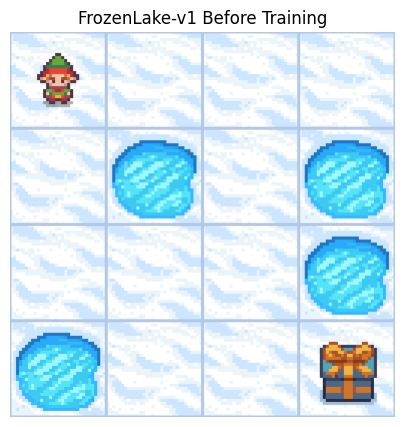

In [3]:
ENV_ID = "FrozenLake-v1"
GAMMA = 0.95
ACTION_NAMES = ["Left", "Down", "Right", "Up"]

env = gym.make(ENV_ID, is_slippery=False)
render_env = gym.make(ENV_ID, is_slippery=False, render_mode="rgb_array")

print("Environment:", ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, info = render_env.reset(seed=7)

plt.figure(figsize=(5, 5))
plt.imshow(render_env.render())
plt.axis("off")
plt.title("FrozenLake-v1 Before Training")
plt.show()

## 2. Q-Learning Update

The update is

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_aQ(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

The behavior policy is $\epsilon$-greedy:

$$
A_t=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon\\
\arg\max_aQ(S_t,a), & \text{with probability }1-\epsilon.
\end{cases}
$$

## 3. Exact Optimal Q-Table $Q^*$

Because FrozenLake is a finite tabular environment with an accessible transition model, we can solve it with value iteration and obtain an exact reference $Q^*$.

This gives us a meaningful convergence measure instead of relying only on episode reward.

In [4]:
def value_iteration_from_model(env, gamma=0.95, theta=1e-12):
    """Compute exact Q* from the environment's tabular transition model P."""
    P = env.unwrapped.P
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    V = np.zeros(n_states)

    while True:
        V_new = np.zeros_like(V)

        for s in range(n_states):
            action_values = []

            for a in range(n_actions):
                q = 0.0

                for prob, s_next, reward, terminated in P[s][a]:
                    bootstrap = 0.0 if terminated else gamma * V[s_next]
                    q += prob * (reward + bootstrap)

                action_values.append(q)

            V_new[s] = max(action_values)

        if np.max(np.abs(V_new - V)) < theta:
            V = V_new
            break

        V = V_new

    Q_star = np.zeros((n_states, n_actions))

    for s in range(n_states):
        for a in range(n_actions):
            for prob, s_next, reward, terminated in P[s][a]:
                bootstrap = 0.0 if terminated else gamma * V[s_next]
                Q_star[s, a] += prob * (reward + bootstrap)

    return Q_star

In [5]:
Q_star = value_iteration_from_model(env, gamma=GAMMA)

q_star_df = pd.DataFrame(
    Q_star,
    index=[f"State {s}" for s in range(env.observation_space.n)],
    columns=ACTION_NAMES
)

print("Exact optimal Q-table Q*:")
display(q_star_df.round(4))

Exact optimal Q-table Q*:


,Left,Down,Right,Up
State 0,0.7351,0.7738,0.7738,0.7351
State 1,0.7351,0.0000,0.8145,0.7738
State 2,0.7738,0.8574,0.7738,0.8145
State 3,0.8145,0.0000,0.7738,0.7738
State 4,0.7738,0.8145,0.0000,0.7351
State 5,0.0000,0.0000,0.0000,0.0000
State 6,0.0000,0.9025,0.0000,0.8145
State 7,0.0000,0.0000,0.0000,0.0000
State 8,0.8145,0.0000,0.8574,0.7738
State 9,0.8145,0.9025,0.9025,0.0000


## 4. Train the Q-Learning Agent

Training uses:

$$
\alpha=0.8,\qquad \gamma=0.95.
$$

Exploration begins at $\epsilon=1$ and decays gradually.

For each episode we record:

- return;
- episode length;
- $\epsilon$;
- RMSE between the learned Q-table and $Q^*$.

We also store the first 60 individual Q-value updates.

In [6]:
def train_q_learning(
    n_episodes=20000,
    alpha=0.8,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.9995,
    seed=7
):
    rng = np.random.default_rng(seed)

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    history = []
    update_log = []
    epsilon = epsilon_start
    update_number = 0

    for episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0

        for step in range(1, 101):
            if rng.random() < epsilon:
                action = int(rng.integers(n_actions))
                selection = "explore"
            else:
                best_actions = np.flatnonzero(np.isclose(Q[state], Q[state].max()))
                action = int(rng.choice(best_actions))
                selection = "exploit"

            next_state, reward, terminated, truncated, _ = env.step(action)

            old_q = Q[state, action]
            max_next_q = 0.0 if terminated else np.max(Q[next_state])
            target = reward if terminated else reward + gamma * max_next_q
            td_error = target - old_q
            Q[state, action] += alpha * td_error

            update_number += 1

            if update_number <= 60:
                update_log.append({
                    "Update": update_number,
                    "Episode": episode,
                    "Step": step,
                    "State": state,
                    "Action": ACTION_NAMES[action],
                    "Reward": reward,
                    "Next State": next_state,
                    "Max Next Q": max_next_q,
                    "Old Q": old_q,
                    "TD Target": target,
                    "TD Error": td_error,
                    "New Q": Q[state, action],
                    "Epsilon": epsilon
                })

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        rmse = np.sqrt(np.mean((Q - Q_star) ** 2))

        history.append({
            "Episode": episode,
            "Return": total_reward,
            "Episode Length": step,
            "Epsilon": epsilon,
            "Q RMSE": rmse
        })

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, pd.DataFrame(history), pd.DataFrame(update_log)

Q, history, update_log = train_q_learning()

print("Training complete.")
print("Final Q RMSE:", history["Q RMSE"].iloc[-1])

Training complete.
Final Q RMSE: 0.0


## 5. First 60 Q-Value Updates

This table exposes the actual learning process rather than jumping directly to the final Q-table.

In [7]:
display(update_log.round(4))

,Update,Episode,Step,State,Action,Reward,Next State,Max Next Q,Old Q,TD Target,TD Error,New Q,Epsilon
0,1,1,1,0,Right,0,1,0.0,0.0,0.0,0.0,0.0,1.0000
1,2,1,2,1,Up,0,1,0.0,0.0,0.0,0.0,0.0,1.0000
2,3,1,3,1,Left,0,0,0.0,0.0,0.0,0.0,0.0,1.0000
3,4,1,4,0,Down,0,4,0.0,0.0,0.0,0.0,0.0,1.0000
4,5,1,5,4,Down,0,8,0.0,0.0,0.0,0.0,0.0,1.0000
5,6,1,6,8,Up,0,4,0.0,0.0,0.0,0.0,0.0,1.0000
6,7,1,7,4,Up,0,0,0.0,0.0,0.0,0.0,0.0,1.0000
7,8,1,8,0,Down,0,4,0.0,0.0,0.0,0.0,0.0,1.0000
8,9,1,9,4,Up,0,0,0.0,0.0,0.0,0.0,0.0,1.0000
9,10,1,10,0,Down,0,4,0.0,0.0,0.0,0.0,0.0,1.0000


## 6. Convergence Graph

The convergence metric is

$$
\operatorname{RMSE}(Q,Q^*)
=
\sqrt{
\frac{1}{|\mathcal S||\mathcal A|}
\sum_{s,a}
\left(Q(s,a)-Q^*(s,a)\right)^2
}.
$$

As the learned Q-table approaches the exact optimal table, RMSE approaches zero.

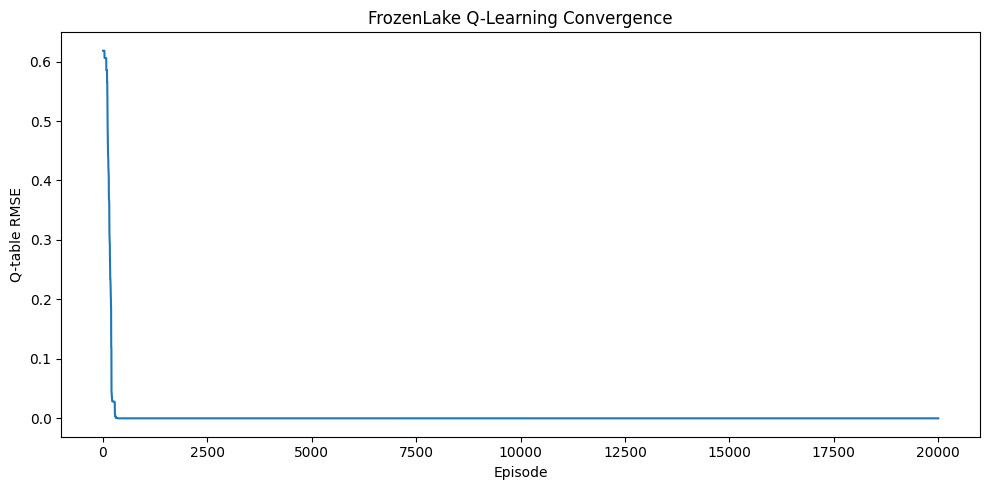

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history["Episode"], history["Q RMSE"])
plt.xlabel("Episode")
plt.ylabel("Q-table RMSE")
plt.title("FrozenLake Q-Learning Convergence")
plt.tight_layout()
plt.show()

## 7. Learned Q-Table vs. Exact Optimal Q-Table

In [9]:
learned_q_df = pd.DataFrame(
    Q,
    index=[f"State {s}" for s in range(env.observation_space.n)],
    columns=ACTION_NAMES
)

comparison = pd.concat(
    {"Learned Q": learned_q_df.round(4), "Exact Q*": q_star_df.round(4)},
    axis=1
)

display(comparison)

Learned Q                         Exact Q*                        
              Left    Down   Right      Up     Left    Down   Right      Up
State 0     0.7351  0.7738  0.7738  0.7351   0.7351  0.7738  0.7738  0.7351
State 1     0.7351  0.0000  0.8145  0.7738   0.7351  0.0000  0.8145  0.7738
State 2     0.7738  0.8574  0.7738  0.8145   0.7738  0.8574  0.7738  0.8145
State 3     0.8145  0.0000  0.7738  0.7738   0.8145  0.0000  0.7738  0.7738
State 4     0.7738  0.8145  0.0000  0.7351   0.7738  0.8145  0.0000  0.7351
State 5     0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000  0.0000
State 6     0.0000  0.9025  0.0000  0.8145   0.0000  0.9025  0.0000  0.8145
State 7     0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000  0.0000
State 8     0.8145  0.0000  0.8574  0.7738   0.8145  0.0000  0.8574  0.7738
State 9     0.8145  0.9025  0.9025  0.0000   0.8145  0.9025  0.9025  0.0000
State 10    0.8574  0.9500  0.0000  0.8574   0.8574  0.9500  0.0000  0.8574
State 11    0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000  0.0000
State 12    0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000  0.0000
State 13    0.0000  0.9025  0.9500  0.8574   0.0000  0.9025  0.9500  0.8574
State 14    0.9025  0.9500  1.0000  0.9025   0.9025  0.9500  1.0000  0.9025
State 15    0.0000  0.0000  0.0000  0.0000   0.0000  0.0000  0.0000  0.0000

## 8. Learned Greedy Policy

The learned policy is

$$
\pi(s)=\arg\max_aQ(s,a).
$$

In [10]:
desc = env.unwrapped.desc.astype("U1")
arrows = np.array(["←", "↓", "→", "↑"])
policy_grid = []

for r in range(desc.shape[0]):
    row = []

    for c in range(desc.shape[1]):
        s = r * desc.shape[1] + c
        tile = desc[r, c]

        if tile in ["H", "G"]:
            row.append(tile)
        elif tile == "S":
            row.append("S" + arrows[np.argmax(Q[s])])
        else:
            row.append(arrows[np.argmax(Q[s])])

    policy_grid.append(row)

policy_df = pd.DataFrame(policy_grid)
display(policy_df)

,0,1,2,3
0,S↓,→,↓,←
1,↓,H,↓,H
2,→,↓,↓,H
3,H,→,→,G


## 9. Evaluate the Trained Agent

In [11]:
def evaluate_agent(Q, n_episodes=500):
    successes = 0
    returns = []

    for episode in range(n_episodes):
        state, _ = env.reset(seed=10000 + episode)
        total_reward = 0.0

        for _ in range(100):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward

            if terminated or truncated:
                break

        returns.append(total_reward)
        successes += int(total_reward > 0)

    return successes / n_episodes, np.mean(returns)

success_rate, mean_return = evaluate_agent(Q)

print(f"Success rate: {success_rate:.3f}")
print(f"Mean return: {mean_return:.3f}")

Success rate: 1.000
Mean return: 1.000


## 10. Run the Trained Agent in the Environment

The following cell uses `render_mode="rgb_array"` and creates an inline GIF that works in Google Colab.

In [12]:
def record_trained_agent(Q, filename="frozenlake_trained_agent.gif"):
    frames = []
    state, _ = render_env.reset(seed=123)
    frames.append(render_env.render())

    for _ in range(100):
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, _ = render_env.step(action)
        frames.append(render_env.render())

        if terminated or truncated:
            break

    save_gif(frames, filename, duration=0.55)

save_gif_code_loaded = True

In [13]:
def save_gif(frames, filename, duration=0.45):
    imageio.mimsave(filename, frames, duration=duration, loop=0)
    display(IPyImage(filename=filename))

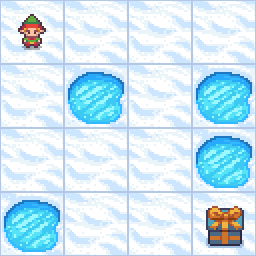

In [14]:
record_trained_agent(Q)

## 11. Portfolio Takeaway

This example shows a complete tabular Q-Learning workflow on an actual Gymnasium environment:

$$
\text{environment}
\rightarrow
\text{Q-Learning}
\rightarrow
\text{Q-table}
\rightarrow
\text{convergence}
\rightarrow
\text{optimal policy}
\rightarrow
\text{rendered trained agent}.
$$